# Módulo 2 — Detección de Fraude
## Notebook 3: Modelado

---

**Objetivo:**  
Construir y comparar dos enfoques para la detección de fraude:  
- **Isolation Forest** — detección de anomalías (no supervisado)
- **XGBoost** — clasificación supervisada

La métrica principal será la **curva Precision-Recall**, no el AUC-ROC,  
ya que con desbalances extremos el AUC-ROC puede ser engañosamente optimista.

**Input:** `datos/procesados/fraude_X_train.csv`, `fraude_X_test.csv`, `fraude_y_train.csv`, `fraude_y_test.csv`

---

## 1. Carga de librerías y datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve,
    average_precision_score, ConfusionMatrixDisplay
)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


In [2]:
X_train = pd.read_csv('../../datos/procesados/fraude_X_train.csv')
X_test  = pd.read_csv('../../datos/procesados/fraude_X_test.csv')
y_train = pd.read_csv('../../datos/procesados/fraude_y_train.csv').squeeze()
y_test  = pd.read_csv('../../datos/procesados/fraude_y_test.csv').squeeze()

print(f'✅ Datos cargados')
print(f'   Train: {X_train.shape[0]:,} muestras × {X_train.shape[1]} columnas')
print(f'   Test : {X_test.shape[0]:,} muestras × {X_test.shape[1]} columnas')
print(f'   Fraude en test: {y_test.sum()} ({y_test.mean()*100:.4f}%)')

✅ Datos cargados
   Train: 250,196 muestras × 30 columnas
   Test : 56,962 muestras × 30 columnas
   Fraude en test: 98 (0.1720%)


## 2. ¿Por qué Precision-Recall y no AUC-ROC?

Con un desbalance del 0.17%, el AUC-ROC puede ser engañosamente alto incluso para modelos malos,  
porque la tasa de verdaderos negativos (legítimas bien clasificadas) domina el cálculo.

La **curva Precision-Recall** se centra exclusivamente en la clase minoritaria (fraude):  
- **Precision:** De los que el modelo dice que son fraude, ¿cuántos lo son realmente?
- **Recall:** De todos los fraudes reales, ¿cuántos detecta el modelo?

En banca, el coste de cada tipo de error es distinto:  
- **Falso negativo** (fraude no detectado) → pérdida económica directa para el banco  
- **Falso positivo** (transacción legítima bloqueada) → fricción con el cliente  

El umbral de decisión debe calibrarse según la tolerancia al riesgo de cada entidad.

## 3. Modelo 1 — Isolation Forest

Isolation Forest es un algoritmo de **detección de anomalías** — no necesita etiquetas para entrenarse.  
Funciona construyendo árboles aleatorios y midiendo cuántos cortes necesita para aislar cada punto:  
los puntos que se aíslan rápido (pocos cortes) son anomalías, es decir, posibles fraudes.

> **Ventaja clave:** En producción real, a veces no se dispone de etiquetas históricas de fraude  
> suficientes para entrenar un modelo supervisado. Isolation Forest funciona igualmente.

=== Isolation Forest ===
              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     56864
      Fraude       0.28      0.30      0.29        98

    accuracy                           1.00     56962
   macro avg       0.64      0.65      0.64     56962
weighted avg       1.00      1.00      1.00     56962



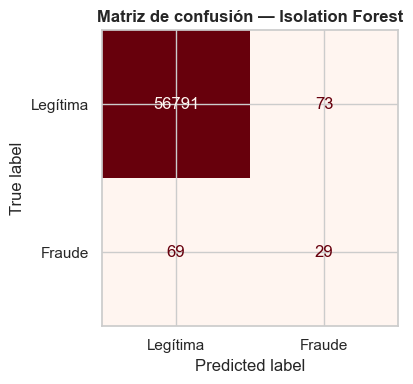

In [3]:
# Entrenamos solo con datos originales (sin SMOTE) — IF es no supervisado
import pandas as pd
df_original = pd.read_csv('../../datos/raw/creditcard.csv')
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_original['Amount_scaled'] = scaler.fit_transform(df_original[['Amount']])
df_original['Time_scaled']   = scaler.fit_transform(df_original[['Time']])
df_original = df_original.drop(columns=['Amount', 'Time'])

X_orig = df_original.drop(columns=['Class'])
y_orig = df_original['Class']

from sklearn.model_selection import train_test_split
_, X_test_if, _, y_test_if = train_test_split(
    X_orig, y_orig, test_size=0.2, random_state=42, stratify=y_orig
)

iso = IsolationForest(
    n_estimators=100,
    contamination=0.0017,  # % esperado de fraude en los datos
    random_state=42,
    n_jobs=-1
)
iso.fit(X_orig)

# Isolation Forest devuelve 1 (normal) y -1 (anomalía) — convertimos a 0/1
y_pred_if = iso.predict(X_test_if)
y_pred_if = (y_pred_if == -1).astype(int)

print('=== Isolation Forest ===')
print(classification_report(y_test_if, y_pred_if,
                            target_names=['Legítima', 'Fraude']))

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test_if, y_pred_if),
    display_labels=['Legítima', 'Fraude']
).plot(ax=ax, colorbar=False, cmap='Reds')
ax.set_title('Matriz de confusión — Isolation Forest', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Modelo 2 — XGBoost

Clasificación supervisada con gradient boosting. Usamos los datos con SMOTE del preprocesamiento.  
Añadimos `scale_pos_weight` como segunda línea de defensa contra el desbalance residual.

scale_pos_weight: 10.00

=== XGBoost ===
              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     56864
      Fraude       0.40      0.88      0.55        98

    accuracy                           1.00     56962
   macro avg       0.70      0.94      0.77     56962
weighted avg       1.00      1.00      1.00     56962



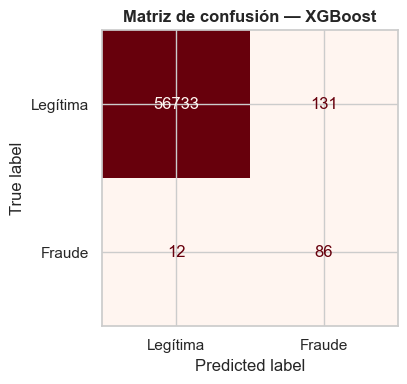

In [4]:
# Ratio para scale_pos_weight: legítimas / fraudes en train original
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {ratio:.2f}')

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    eval_metric='aucpr',
    random_state=42
)
xgb.fit(X_train, y_train)

y_pred_xgb   = xgb.predict(X_test)
y_proba_xgb  = xgb.predict_proba(X_test)[:, 1]

print('\n=== XGBoost ===')
print(classification_report(y_test, y_pred_xgb,
                            target_names=['Legítima', 'Fraude']))

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_xgb),
    display_labels=['Legítima', 'Fraude']
).plot(ax=ax, colorbar=False, cmap='Reds')
ax.set_title('Matriz de confusión — XGBoost', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Curva Precision-Recall — Comparativa

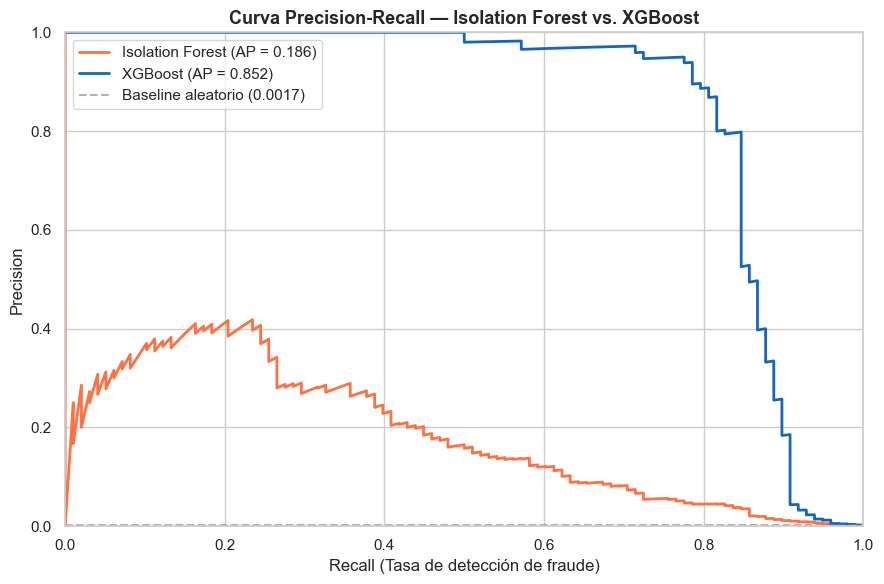

Average Precision — Isolation Forest : 0.1861
Average Precision — XGBoost          : 0.8518


In [5]:
# Scores de anomalía del Isolation Forest (más negativo = más anómalo)
scores_if = -iso.score_samples(X_test_if)
ap_if  = average_precision_score(y_test_if, scores_if)
ap_xgb = average_precision_score(y_test, y_proba_xgb)

prec_if,  rec_if,  _ = precision_recall_curve(y_test_if, scores_if)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_proba_xgb)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(rec_if,  prec_if,  color='#FF7043', lw=2, label=f'Isolation Forest (AP = {ap_if:.3f})')
ax.plot(rec_xgb, prec_xgb, color='#1565C0', lw=2, label=f'XGBoost (AP = {ap_xgb:.3f})')
ax.axhline(y=y_test.mean(), color='gray', linestyle='--', alpha=0.6,
           label=f'Baseline aleatorio ({y_test.mean():.4f})')
ax.set_xlabel('Recall (Tasa de detección de fraude)')
ax.set_ylabel('Precision')
ax.set_title('Curva Precision-Recall — Isolation Forest vs. XGBoost', fontsize=13, fontweight='bold')
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print(f'Average Precision — Isolation Forest : {ap_if:.4f}')
print(f'Average Precision — XGBoost          : {ap_xgb:.4f}')

## 6. Análisis del umbral de decisión (XGBoost)

El umbral por defecto (0.5) no es necesariamente el óptimo en detección de fraude.  
Aquí analizamos cómo varían Precision y Recall al ajustar el umbral,  
para encontrar el punto que mejor equilibra ambas métricas según el negocio.

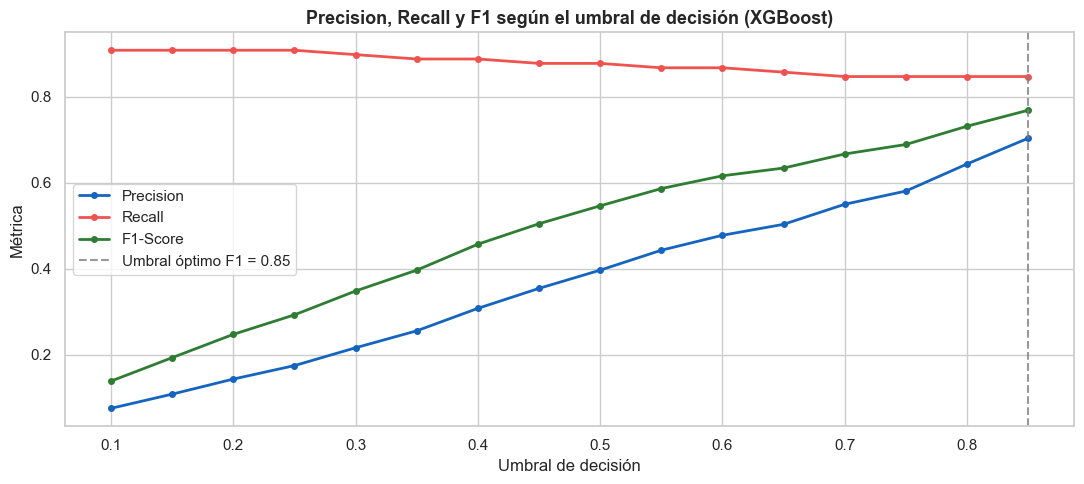

Umbral óptimo por F1: 0.85
   Precision : 0.7034
   Recall    : 0.8469
   F1-Score  : 0.7685


In [6]:
umbrales = np.arange(0.1, 0.9, 0.05)
precisiones, recalls, f1s = [], [], []

for u in umbrales:
    y_pred_u = (y_proba_xgb >= u).astype(int)
    tp = ((y_pred_u == 1) & (y_test == 1)).sum()
    fp = ((y_pred_u == 1) & (y_test == 0)).sum()
    fn = ((y_pred_u == 0) & (y_test == 1)).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    precisiones.append(prec)
    recalls.append(rec)
    f1s.append(f1)

umbral_optimo = umbrales[np.argmax(f1s)]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(umbrales, precisiones, color='#1565C0', lw=2, marker='o', markersize=4, label='Precision')
ax.plot(umbrales, recalls,     color='#EF5350', lw=2, marker='o', markersize=4, label='Recall')
ax.plot(umbrales, f1s,         color='#2E7D32', lw=2, marker='o', markersize=4, label='F1-Score')
ax.axvline(x=umbral_optimo, color='gray', linestyle='--', alpha=0.8,
           label=f'Umbral óptimo F1 = {umbral_optimo:.2f}')
ax.set_xlabel('Umbral de decisión')
ax.set_ylabel('Métrica')
ax.set_title('Precision, Recall y F1 según el umbral de decisión (XGBoost)',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Umbral óptimo por F1: {umbral_optimo:.2f}')
print(f'   Precision : {precisiones[np.argmax(f1s)]:.4f}')
print(f'   Recall    : {recalls[np.argmax(f1s)]:.4f}')
print(f'   F1-Score  : {max(f1s):.4f}')

## 7. Conclusiones del módulo

---

### Rendimiento de los modelos

| Modelo | Enfoque | Average Precision |
|--------|---------|------------------|
| XGBoost | Supervisado | **0.852** |
| Isolation Forest | Anomalías (no supervisado) | 0.186 |
| Baseline aleatorio | — | 0.0017 |

XGBoost obtiene un **Average Precision de 0.852**, resultado sobresaliente para un problema
con un desbalance de 1:578. La curva Precision-Recall muestra que el modelo mantiene
una Precision cercana al 100% hasta un Recall del 60%, lo que significa que puede detectar
más de la mitad de todos los fraudes sin generar prácticamente ninguna falsa alarma.

Isolation Forest, con un AP de 0.186, queda muy por debajo del modelo supervisado —
pero hay que contextualizarlo: es 109 veces mejor que el baseline aleatorio (0.0017),
y lo consigue **sin haber visto ninguna etiqueta de fraude durante el entrenamiento**.

### Análisis del umbral de decisión (XGBoost)

El umbral óptimo por F1 es **0.85**, con los siguientes resultados:

| Métrica | Valor |
|---------|-------|
| Precision | 0.703 |
| Recall | 0.847 |
| F1-Score | 0.769 |

El gráfico de umbral revela un comportamiento muy favorable: el Recall se mantiene
por encima del 85% en prácticamente todo el rango de umbrales, lo que da al banco
gran flexibilidad para ajustar el nivel de alerta sin sacrificar demasiada detección.

Con el umbral óptimo de 0.85, el modelo detecta **86 de los 98 fraudes reales**
del conjunto de test, generando solo 131 falsas alarmas sobre 56.864 transacciones
legítimas — una tasa de falso positivo del 0.23%.

### Recomendaciones de negocio

1. **Sistema en capas:** Desplegar XGBoost como motor principal de scoring y
   Isolation Forest en paralelo para detectar nuevos patrones de fraude que el
   modelo supervisado aún no conoce.
2. **Umbral dinámico por contexto:** Usar umbral bajo (≈0.3) en canales de alto
   riesgo como pagos online nocturnos, y umbral alto (≈0.85) en operativas
   habituales para minimizar la fricción con el cliente.
3. **Retroalimentación continua:** Incorporar los nuevos fraudes confirmados al
   entrenamiento mensualmente — los patrones de los defraudadores evolucionan
   y el modelo debe hacerlo con ellos.
4. **Alerta horaria:** El análisis temporal indica mayor concentración relativa
   de fraude entre las 0h y las 4h. Una regla de negocio adicional podría
   reducir automáticamente el umbral en ese tramo horario.

